# Очистка чертежа: классификация штрихов и поиск наконечников

| шаг | что делает | результат |
|---|---|---|
| 1 | загрузка, единый масштаб | `img_bgr` |
| 2 | детекция текста (PP-OCRv5 det) | `text_region` |
| 3 | бинаризация | `binary`, `fg` |
| 4 | толщина штриха через distance transform | `thickness_map`, `t_axis` |
| 5 | граф скелета, текстовые рёбра | `graph`, `is_text_edge` |
| 6 | классы толщины, KMeans **без текстовых рёбер** | `cls_img` |
| 7 | класс ребра по большинству голосов | `cls_vote` |
| 8 | удаление тонких линий и текста | `mask_thick` |
| 9 | наконечники как пики ширины | `mask_clean` |

Текст ищется не ради самого текста, а чтобы буквы не смещали распределение толщин, по которому
KMeans ставит границы классов. Поэтому граф строится **до** кластеризации: чистить выборку надо
целыми рёбрами, а не пикселями внутри прямоугольника.

Параметры задаются слайдерами. Каждая такая ячейка кончается объектом `ui_*`, результат лежит
в `ui_*.result` и распаковывается в начале следующей ячейки. Подвинул слайдер — перезапусти
ячейки ниже.

## 1. Загрузка и масштаб

Импорты и палитра классов — единственное место в ноутбуке, где что-то импортируется.

In [35]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from ipywidgets import Checkbox, Dropdown, FloatSlider, IntSlider, interactive
from matplotlib import pyplot as plt
from scipy import ndimage as ndi
from scipy.signal import argrelmin
from scipy.stats import gaussian_kde
from skan import Skeleton, summarize
from skimage.filters import threshold_multiotsu
from skimage.morphology import skeletonize
from sklearn.cluster import HDBSCAN, AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import BayesianGaussianMixture, GaussianMixture

PALETTE = [(70, 130, 255), (60, 200, 90), (255, 190, 40), (255, 70, 70), (200, 80, 255), (0, 220, 220)]

Список файлов датасета.

In [2]:
folder = Path("D:/datasets/Сравнение чертежей/Эскизы датасет")
files = sorted(folder.glob("*.jpg"))

print(f"файлов: {len(files)}")

файлов: 21


Приводим длинную сторону к единому размеру — это **единственный** ресайз пайплайна.

Вверх бикубикой: она восстанавливает по серой кайме вокруг штриха плавный градиент, порог режет
край субпиксельно, и толщины перестают слипаться при квантовании distance transform. Вниз
`INTER_AREA`. Само по себе увеличение классы не разводит (силуэт инвариантен к умножению всех
толщин на константу) — работает именно де-квантизация.

In [3]:
def load_image(file_path):
    """Загрузка изображения в формате BGR из файла."""
    data = np.fromfile(str(file_path), dtype=np.uint8)
    image = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError(f"Could not load image from {file_path}")
    return image


def resize_det_image(image, max_size=4000):
    """Приводит длинную сторону к max_size (вверх или вниз), потолок — 4000."""
    max_size = min(max_size, 4000)
    height, width = image.shape[:2]
    side = max(height, width)
    if side == max_size:
        return image

    k = max_size / float(side)
    interp = cv2.INTER_AREA if k < 1 else cv2.INTER_CUBIC
    return cv2.resize(image, (round(width * k), round(height * k)), interpolation=interp)

In [ ]:
def run_load_image(idx):
    """Загрузка и изменение размера изображения по индексу."""
    path = files[idx]
    img_bgr = load_image(path)
    h, w = img_bgr.shape[:2]
    print(f"[{idx}] {path.stem} — {w}x{h}")
    plt.figure(figsize=(16, 8))
    plt.imshow(img_bgr[..., ::-1])  # BGR to RGB
    plt.axis("off")
    plt.show()
    return img_bgr


ui_load = interactive(
    run_load_image,
    idx=Dropdown(
        options=[(f"[{i}] {f.stem}", i) for i, f in enumerate(files)],
        value=6,
        description="файл",
    ),
)
ui_load

interactive(children=(Dropdown(description='файл', index=6, options=(('[0] 1', 0), ('[1] 10', 1), ('[2] 11', 2…

## 2. Детекция текста

Цель — не удалить текст, а исключить его из выборки, по которой оцениваются границы классов
толщины в шаге 5. Поэтому маска может быть грубой: мы ничего не стираем, а только не учитываем.

Препроцессинг. DBNet требует размер, кратный 32; добираем его **паддингом белым**, а не ресайзом,
чтобы масштаб остался ровно 1.0 и маска легла на штрихи попиксельно. Нормализация — из
`PP-OCRv5_server_det.yml`: scale 1/255, ImageNet mean/std.

In [449]:
def pad_to_stride(img):
    """Добавление паддинга к изображению так, чтобы его размеры были кратны 32."""
    h, w = img.shape[:2]
    ph, pw = (-h) % 32, (-w) % 32
    if ph == 0 and pw == 0:
        return img, 0, 0
    return cv2.copyMakeBorder(img, 0, ph, 0, pw, cv2.BORDER_CONSTANT, value=(255,) * 3), ph, pw


def to_blob(img):
    """Преобразование изображения в blob для подачи в нейросеть."""
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    return ((rgb - mean) / std).transpose(2, 0, 1)[np.newaxis, ...]

In [450]:
img_bgr = ui_load.result

In [451]:
img_det, pad_h, pad_w = pad_to_stride(img_bgr)
blob = to_blob(img_det)

h, w = img_bgr.shape[:2]
dh, dw = img_det.shape[:2]
print(f"{w}x{h} -> {dw}x{dh} | добавлено строк {pad_h}, столбцов {pad_w} | h%32={dh % 32} w%32={dw % 32}")
print(f"оригинал не тронут: {np.array_equal(img_det[:h, :w], img_bgr)}")
print(f"blob {blob.shape} {blob.dtype} | min {blob.min():.3f} max {blob.max():.3f} | {blob.nbytes / 1024**2:.0f} MB")

1475x919 -> 1504x928 | добавлено строк 9, столбцов 29 | h%32=0 w%32=0
оригинал не тронут: True
blob (1, 3, 928, 1504) float32 | min -2.118 max 2.640 | 16 MB


Прогон сети и обрезка полосы паддинга. Карта вероятностей `prob` совпадает с `img_bgr` попиксельно.

In [452]:
import onnxruntime as ort

det_session = ort.InferenceSession("./models/PP-OCRv5_server_det_infer.onnx")
input_name = det_session.get_inputs()[0].name
print(f"вход: {input_name} | {det_session.get_inputs()[0].shape}")

вход: x | ['DynamicDimension.0', 3, 'DynamicDimension.1', 'DynamicDimension.2']


In [453]:
def run_detection(blob):
    """Запуск детекции на изображении."""
    outputs = det_session.run(None, {input_name: blob})
    return outputs[0]  # предполагаем, что первый выход - это маска детекции


def process_detection_output(outputs, pad_h, pad_w, target_shape=None):
    """Снимает паддинг и (опционально) возвращает карту в разрешение оригинала."""
    h, w = outputs.shape[-2:]
    outputs = outputs[0, 0, : h - pad_h, : w - pad_w]

    if target_shape is not None:
        h0, w0 = target_shape[:2]
        interp = cv2.INTER_AREA if outputs.shape[0] > h0 else cv2.INTER_LINEAR
        outputs = cv2.resize(outputs.astype(np.float32), (w0, h0), interpolation=interp)

    return outputs


def multiscale_detection(image, scales=[640, 1600, 2600]) -> np.ndarray:
    """Запуск детекции на изображении с использованием нескольких масштабов."""
    maps = []
    for scale in scales:
        img_rescaled = resize_det_image(image, max_size=scale)
        print(f"размер {img_rescaled.shape[1]}x{img_rescaled.shape[0]}")
        img_det, pad_h, pad_w = pad_to_stride(img_rescaled)
        blob = to_blob(img_det)
        outputs = run_detection(blob)
        # Убираем паддинг из выхода
        m = process_detection_output(outputs, pad_h, pad_w, target_shape=image.shape)
        maps.append(m)
    return np.stack(maps)

In [454]:
scales = [320, 640, 2000]
maps = multiscale_detection(img_bgr, scales=scales)
print(f"stack: {maps.shape}, {maps.dtype}")

размер 320x199
размер 640x399
размер 2000x1246
stack: (3, 919, 1475), float32


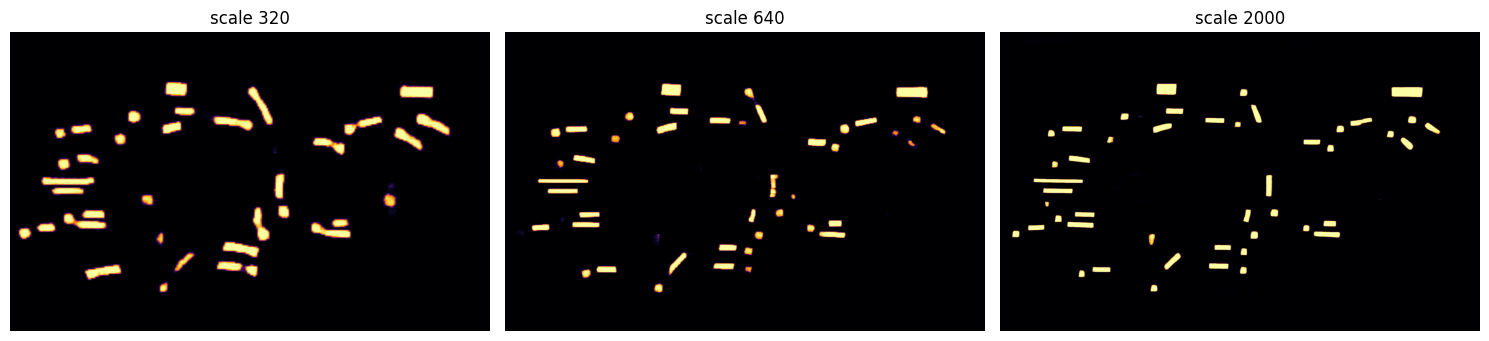

In [455]:
fig, axes = plt.subplots(1, len(maps), figsize=(5 * len(maps), 5))
for ax, m, s in zip(axes, maps, scales, strict=True):
    ax.imshow(m, cmap="inferno", vmin=0, vmax=1)
    ax.set_title(f"scale {s}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [456]:
def classify_maps(maps: np.ndarray, method: str = "mean", thr: float = 0.3) -> np.ndarray:
    """Стек карт вероятностей (S, H, W) -> бинарная маска (H, W) uint8 {0, 255}."""
    prob = {
        "max": maps.max,
        "mean": maps.mean,
        "min": maps.min,
        "median": lambda axis: np.median(maps, axis=axis),
    }[method](axis=0)
    return prob, ((prob > thr) * 255).astype(np.uint8)


prob, mask = classify_maps(maps, method="mean", thr=0.3)
print(f"prob: {prob.shape} {prob.dtype} min={prob.min():.3f} max={prob.max():.3f}")
print(f"mask: {(mask > 0).mean() * 100:.2f}% пикселей, компонент: {cv2.connectedComponents(mask)[0] - 1}")


prob: (919, 1475) float32 min=0.000 max=1.000
mask: 3.80% пикселей, компонент: 43


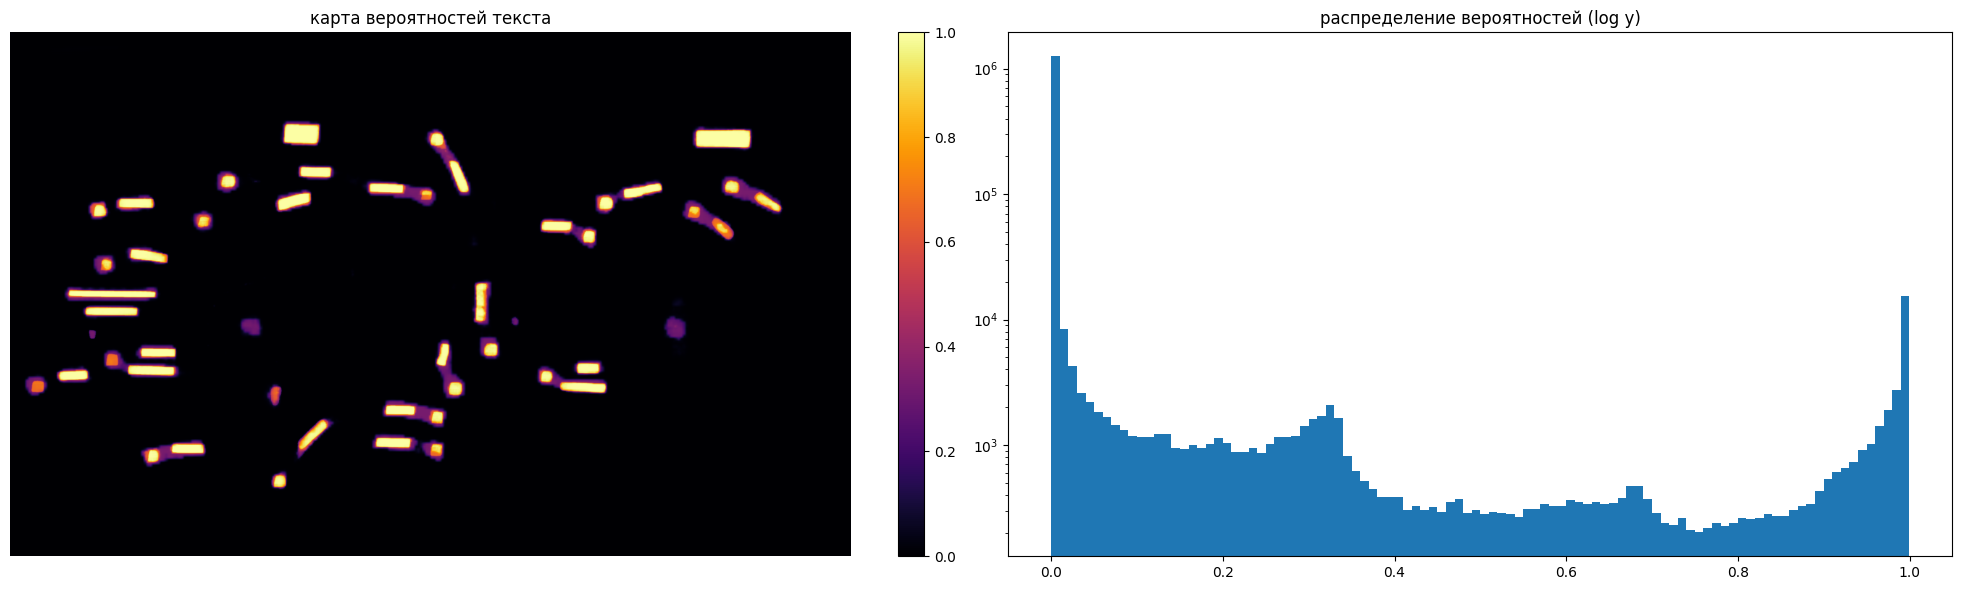

In [457]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
im = ax[0].imshow(prob, cmap="inferno", vmin=0, vmax=1)
ax[0].set_title("карта вероятностей текста")
ax[0].axis("off")
plt.colorbar(im, ax=ax[0], fraction=0.03)
ax[1].hist(prob.ravel(), bins=100, log=True)
ax[1].set_title("распределение вероятностей (log y)")
plt.tight_layout()
plt.show()

Кандидаты по логике `DBPostProcess`: контуры бинарной карты, `minAreaRect`, **средняя вероятность
внутри прямоугольника**. Порог `thresh` отвечает только за связность, решение принимает
`box_thresh` по этой средней. Площадь кандидата тут не участвует вообще.

In [458]:
def box_score(prob, box):
    """Средняя вероятность внутри четырёхугольника — score из DBPostProcess."""
    hh, ww = prob.shape[:2]
    b = box.copy()
    xmin, xmax = np.clip([np.floor(b[:, 0].min()), np.ceil(b[:, 0].max())], 0, ww - 1).astype(np.int32)
    ymin, ymax = np.clip([np.floor(b[:, 1].min()), np.ceil(b[:, 1].max())], 0, hh - 1).astype(np.int32)
    m = np.zeros((ymax - ymin + 1, xmax - xmin + 1), dtype=np.uint8)
    b[:, 0] -= xmin
    b[:, 1] -= ymin
    cv2.fillPoly(m, b.reshape(1, -1, 2).astype(np.int32), 1)
    return cv2.mean(prob[ymin : ymax + 1, xmin : xmax + 1], m)[0]


def db_candidates(prob, thresh, box_thresh, min_size, max_candidates=1000):
    """Только отбор кандидатов. Маска строится отдельно — чтобы отбор можно было смотреть сам по себе."""
    cnts, _ = cv2.findContours((prob > thresh).astype(np.uint8), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    rows = []
    for c in cnts[:max_candidates]:
        rect = cv2.minAreaRect(c)
        (rw, rh) = rect[1]
        area, perim = cv2.contourArea(c), cv2.arcLength(c, True)
        rows.append(
            dict(
                score=box_score(prob, cv2.boxPoints(rect)),
                sside=min(rw, rh),
                lside=max(rw, rh),
                area=area,
                perim=perim,
                fill=area / (rw * rh) if rw * rh else 0.0,
                cnt=c,
            )
        )
    df = pd.DataFrame(rows)
    if len(df):
        df["keep"] = (df.score >= box_thresh) & (df.sside >= min_size) & (df.perim > 0)
    return df, len(cnts)


def show_candidates(thresh, box_thresh, min_size):
    df, n_all = db_candidates(prob, thresh, box_thresh, min_size)
    if n_all > 1000:
        print(f"ВНИМАНИЕ: контуров {n_all}, лимит 1000 обрезал список")
    if not len(df):
        print("кандидатов нет")
        return df

    print(f"кандидатов {len(df)} | принято {int(df.keep.sum())} | отброшено {int((~df.keep).sum())}")
    print("\n5 крупнейших по площади:")
    print(df.drop(columns="cnt").sort_values("area", ascending=False).head(5).round(3).to_string())

    fig, ax = plt.subplots(1, 2, figsize=(18, 5))
    ax[0].hist(df.score, bins=40)
    ax[0].axvline(box_thresh, color="r", ls="--")
    ax[0].set_title("score кандидатов")
    ax[1].scatter(df.area, df.score, s=14, c=np.where(df.keep, "green", "red"))
    ax[1].axhline(box_thresh, color="r", ls="--")
    ax[1].set_xscale("log")
    ax[1].set_xlabel("площадь, px (log)")
    ax[1].set_ylabel("score")
    ax[1].set_title("разделяет score, а не площадь")
    plt.tight_layout()
    plt.show()
    return df


ui_cand = interactive(
    show_candidates,
    thresh=FloatSlider(value=0.3, min=0.05, max=0.9, step=0.05, continuous_update=False, description="thresh"),
    box_thresh=FloatSlider(value=0.4, min=0.1, max=0.95, step=0.05, continuous_update=False, description="box_thresh"),
    min_size=IntSlider(value=3, min=0, max=30, step=1, continuous_update=False, description="min_size"),
)
ui_cand

interactive(children=(FloatSlider(value=0.3, continuous_update=False, description='thresh', max=0.9, min=0.05,…

Маска текстовой области: контур каждого принятого ядра раздувается на `d = area·ratio/perimeter`.
Раздуваем сам контур, а не описанный прямоугольник, — форма идёт вдоль наклонных надписей и
захватывает меньше лишнего. Бери с запасом: лишний захват линии стоит дёшево, пропущенный текст — дорого.

In [459]:
df_cand = ui_cand.result
assert df_cand is not None and len(df_cand), "кандидатов нет — ослабь thresh в предыдущей ячейке"


def build_region(unclip_ratio):
    region = np.zeros((h, w), np.uint8)
    kept = df_cand[df_cand.keep]
    for c, area, perim in zip(kept.cnt, kept.area, kept.perim):
        d = int(round(area * unclip_ratio / perim))
        x, y, bw, bh = cv2.boundingRect(c)
        pad = d + 2
        x0, y0 = max(0, x - pad), max(0, y - pad)
        x1, y1 = min(w, x + bw + pad), min(h, y + bh + pad)

        sub = np.zeros((y1 - y0, x1 - x0), np.uint8)
        cv2.drawContours(sub, [c - np.array([[x0, y0]])], -1, 255, cv2.FILLED)
        if d > 0:
            dist = cv2.distanceTransform(np.where(sub > 0, 0, 255).astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
            sub = np.where((dist <= d) | (sub > 0), 255, 0).astype(np.uint8)
        region[y0:y1, x0:x1] = np.maximum(region[y0:y1, x0:x1], sub)

    core_u8 = np.zeros((h, w), np.uint8)
    for c in kept.cnt:
        cv2.drawContours(core_u8, [c], -1, 255, cv2.FILLED)
    core_px = core_u8 > 0

    print(f"принятых ядер {len(kept)} | ядро {core_px.mean() * 100:.3f}% -> область {(region > 0).mean() * 100:.3f}%")

    overlay = img_bgr.copy()
    overlay[region > 0] = (0, 0, 255)
    overlay[core_px] = (0, 140, 255)
    blend = cv2.addWeighted(overlay, 0.45, img_bgr, 0.55, 0)

    plt.figure(figsize=(18, 10))
    plt.imshow(cv2.cvtColor(blend, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"оранжевое — ядро сети, красное — раздутие на unclip {unclip_ratio}")
    plt.show()
    return region > 0


ui_region = interactive(
    build_region,
    unclip_ratio=FloatSlider(value=1.5, min=0.0, max=4.0, step=0.1, continuous_update=False, description="unclip"),
)
ui_region

interactive(children=(FloatSlider(value=1.5, continuous_update=False, description='unclip', max=4.0), Output()…

## 3. Бинаризация

Штрих тёмный на светлом, отсюда `THRESH_BINARY_INV`. Размытие гасит зерно JPEG: без него тонкие
линии рвутся, а разрыв плодит ложные концы в графе. Otsu ставит порог по гистограмме сам;
ручной режим нужен на сканах с неровным фоном.

In [460]:
def resize_image(image, scale=2.0):
    """Изменение размера изображения с сохранением пропорций."""
    h, w = image.shape[:2]
    new_w, new_h = int(w * scale), int(h * scale)
    return cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)


def to_gray(image):
    """Преобразование изображения в оттенки серого."""
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


def otsu_image(image, threshold=0):
    """Преобразование изображения в бинарное с использованием заданного порога."""
    thr, fg = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return fg, thr

In [461]:
text_region = ui_region.result
SCALE = 2.0
resized = resize_image(img_bgr, scale=SCALE)
text_region_resized = resize_image(text_region.astype(np.uint8) * 255, scale=SCALE) > 0
text_region = text_region_resized.astype(bool)
gray = to_gray(resized)


def binarize():
    blurred = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)
    binary, thr = otsu_image(blurred)

    fg = binary > 0

    plt.figure(figsize=(16, 8))
    plt.imshow(fg, cmap="gray")
    plt.axis("off")
    plt.title(f"бинаризация Otsu | порог {thr:.0f}")
    plt.show()
    return fg, binary


ui_binary = interactive(binarize)
ui_binary



interactive(children=(Output(),), _dom_classes=('widget-interact',))

## 4. Толщина штриха

`distanceTransform` даёт расстояние до фона, то есть половину локальной ширины. Значения снимаем
**только с медиальной оси**: на краях штриха оценка занижена по построению и смазывает гистограмму.
Параметров нет; ячейка дорогая, поэтому и вынесена отдельно от подбора классов.

In [462]:
def path_thickness(skeleton, dist, trim=0.25):
    """Толщина = медиана (2r-1) по срединной части пути: узлы и концы отброшены."""
    n_px = np.diff(skeleton.paths.indptr)
    pid = np.repeat(np.arange(skeleton.n_paths), n_px)
    pos = np.arange(len(pid)) - np.repeat(skeleton.paths.indptr[:-1], n_px)
    keep = (pos >= trim * np.repeat(n_px, n_px)) & (pos < (1 - trim) * np.repeat(n_px, n_px))

    rc = skeleton.coordinates[skeleton.paths.indices].astype(int)
    vals = 2 * dist[rc[:, 0], rc[:, 1]] - 1
    med = pd.Series(vals[keep]).groupby(pid[keep]).median()
    return med.reindex(np.arange(skeleton.n_paths)).to_numpy()  # длина всегда n_paths


def area_thickness(owner, skeleton, summary):
    """Толщина = площадь принадлежащих ребру пикселей / длина ребра."""
    area = np.bincount(owner[owner >= 0], minlength=skeleton.n_paths).astype(float)
    return area / np.maximum(summary["branch-distance"].to_numpy(), 1.0)


def path_id_image(skeleton, shape):
    """Карта пикселей скелета -> индекс пути (-1 вне скелета)."""
    img = np.full(shape, -1, dtype=np.int32)
    rc = skeleton.coordinates[skeleton.paths.indices].astype(int)
    img[rc[:, 0], rc[:, 1]] = np.repeat(np.arange(skeleton.n_paths), np.diff(skeleton.paths.indptr))
    return img


def owner_image(pid_img, fg):
    """Каждый пиксель переднего плана относим к ближайшему пути скелета (-1 вне штрихов)."""
    _, lbl = cv2.distanceTransformWithLabels(
        (pid_img < 0).astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE, labelType=cv2.DIST_LABEL_PIXEL
    )
    on_skel = pid_img >= 0
    lut = np.full(int(lbl.max()) + 1, -1, dtype=np.int32)
    lut[lbl[on_skel]] = pid_img[on_skel]
    return np.where(fg, lut[lbl], -1)


In [463]:
def ink_map(gray, fg, skel, dist):
    """Мягкая «чернильность» 0..1. Бумага оценивается локально, поэтому неровный тон не мешает."""
    k = 2 * int(3 * np.median(dist[skel])) + 1  # ядро заведомо шире любого штриха
    paper = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, np.ones((k, k), np.uint8)).astype(np.float32)
    ink_level = float(np.percentile(gray[fg], 5))
    return np.clip((paper - gray) / np.maximum(paper - ink_level, 1.0), 0.0, 1.0), k


def equivalent_thickness(ink, owner_ink, n_paths, branch_len):
    """Эквивалентная ширина ребра = весь собранный им объём чернил / длина. Порога не содержит."""
    sel = owner_ink >= 0
    total = np.bincount(owner_ink[sel], weights=ink[sel], minlength=n_paths)
    return total / np.maximum(branch_len, 1.0)


In [464]:
fg, binary = ui_binary.result
skel = skeletonize(fg)
dist = cv2.distanceTransform(binary, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)

skeleton = Skeleton(skel)
summary = summarize(skeleton, separator="-")
owner = owner_image(path_id_image(skeleton, skel.shape), fg)
thickness = path_thickness(skeleton, dist)
summary["thickness"] = thickness
summary["thickness_area"] = area_thickness(owner, skeleton, summary)

print(f"путей {skeleton.n_paths} | покрыто штрихов {(owner >= 0).sum() / fg.sum():.1%}")
print(summary[["branch-distance", "branch-type", "thickness", "thickness_area"]].describe().round(2))

путей 1077 | покрыто штрихов 100.0%
       branch-distance  branch-type  thickness  thickness_area
count          1077.00      1077.00    1077.00         1077.00
mean             46.31         1.48       3.98            4.24
std             160.63         0.72       2.45            2.63
min               1.00         0.00       1.00            0.00
25%               5.83         1.00       3.00            2.66
50%              16.66         2.00       3.00            3.64
75%              44.80         2.00       5.00            5.27
max            4786.90         3.00      15.12           27.22


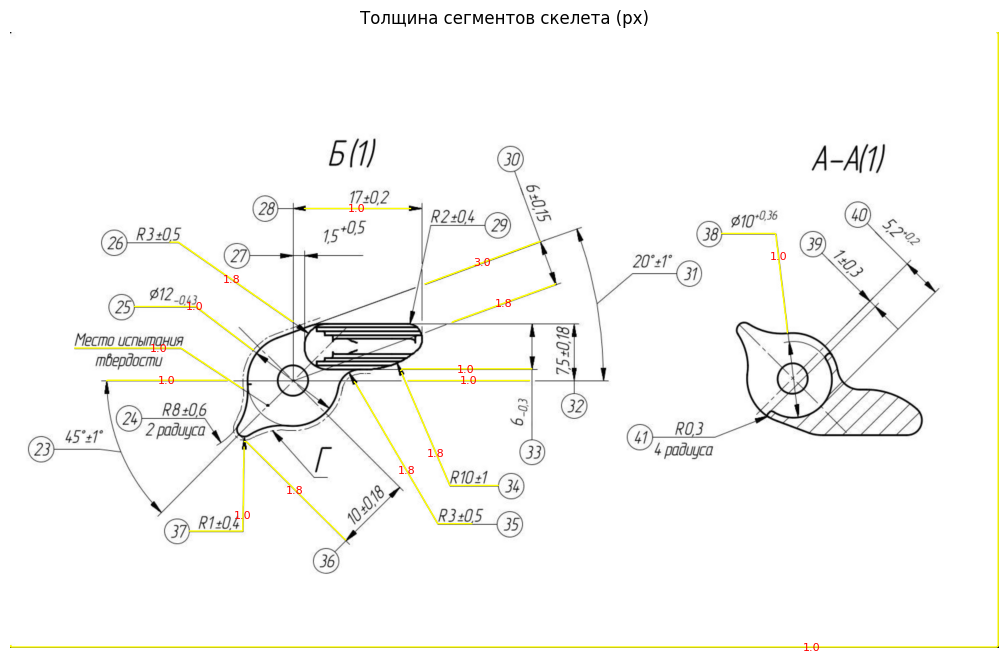

In [465]:
plt.figure(figsize=(16, 8))
plt.imshow(resized[..., ::-1])
for i in range(skeleton.n_paths):
    coords = skeleton.path_coordinates(i)
    if len(coords) < 300:  # мусорные обрубки не подписываем
        continue
    mid = coords[len(coords) // 2]
    plt.plot(coords[:, 1], coords[:, 0], color="yellow", linewidth=1.0)
    plt.text(
        mid[1], mid[0], f"{summary['thickness'].to_numpy()[i]:.1f}", color="red", fontsize=8, ha="center", va="center"
    )
plt.axis("off")
plt.title("Толщина сегментов скелета (px)")
plt.show()


In [466]:
def text_ratio(skeleton, text_region):
    """Доля пикселей каждого пути, попавших в текстовые области. -> (n_paths,)"""
    rc = skeleton.coordinates[skeleton.paths.indices].astype(int)
    pid = np.repeat(np.arange(skeleton.n_paths), np.diff(skeleton.paths.indptr))
    return pd.Series(text_region[rc[:, 0], rc[:, 1]]).groupby(pid).mean().to_numpy()

In [467]:
t_ratio = text_ratio(skeleton, text_region)
is_text = t_ratio > 0.8

print(f"текстовых рёбер {is_text.sum()}/{skeleton.n_paths} ({is_text.mean():.1%})")
print(f"их доля длины {summary.loc[is_text, 'branch-distance'].sum() / summary['branch-distance'].sum():.1%}")
print(
    f"толщина: текст {np.nanmedian(thickness[is_text]):.2f} px | остальное {np.nanmedian(thickness[~is_text]):.2f} px"
)

текстовых рёбер 582/1077 (54.0%)
их доля длины 37.3%
толщина: текст 3.00 px | остальное 5.00 px


In [468]:
t = summary["thickness"].to_numpy()
segments = [skeleton.path_coordinates(i)[:, ::-1] for i in range(skeleton.n_paths)]


def run_split(pct):
    """Синие — тоньше порога, красные — толще. Ручка: сколько процентов рёбер уходит в синие."""
    thr = np.percentile(t, pct)
    thick = t > thr
    colors = np.where(thick[:, None], (0.95, 0.25, 0.25), (0.25, 0.45, 0.95))

    print(f"{pct:.0f}% рёбер -> порог {thr:.1f} px ({thr / SCALE:.1f} px оригинала)")
    print(f"синих {int((~thick).sum())} | красных {int(thick.sum())} из {len(t)}")

    fig, ax = plt.subplots(figsize=(18, 10))
    ax.imshow(resized[..., ::-1])
    ax.add_collection(LineCollection(segments, colors=colors, linewidths=1.4))
    ax.axis("off")
    ax.set_title(f"{pct:.0f}% = {thr:.1f} px: синие ниже, красные выше")
    plt.show()
    return thr


ui_split = interactive(
    run_split,
    pct=FloatSlider(value=45, min=0, max=100, step=1, continuous_update=False, description="порог, %"),
)
ui_split


interactive(children=(FloatSlider(value=45.0, continuous_update=False, description='порог, %', step=1.0), Outp…

In [ ]:
from matplotlib.collections import LineCollection

thr = ui_split.result
branch_len = summary["branch-distance"].to_numpy()
btype = summary["branch-type"].to_numpy()
TYPES = {0: "конец-конец", 1: "узел-конец", 2: "узел-узел", 3: "цикл"}
thick = t > thr

def run_prune(max_len):
    """Удаляем короткие толстые рёбра типа «узел-узел» — висят на пересечении обоими концами."""
    drop = thick & (btype == 2) & (branch_len < max_len)

    print(f"порог толщины {thr:.1f} px | короткое = длина < {max_len} px ({max_len / SCALE:.0f} px оригинала)")
    print("толстые по типам: " + " | ".join(f"{TYPES[k]} {int((thick & (btype == k)).sum())}" for k in TYPES))
    print(f"удаляем {int(drop.sum())} из {int((thick & (btype == 2)).sum())} толстых «узел-узел»")
    if drop.any():
        print(f"удаляемые: длина медиана {np.median(branch_len[drop]):.0f} px | толщина медиана {np.median(t[drop]):.1f} px")

    colors = np.where(drop[:, None], (0.2, 0.9, 0.2), np.where(thick[:, None], (0.95, 0.25, 0.25), (0.25, 0.45, 0.95)))

    fig, ax = plt.subplots(figsize=(18, 10))
    ax.imshow(resized[..., ::-1])
    ax.add_collection(LineCollection(segments, colors=colors, linewidths=1.4))
    ax.axis("off")
    ax.set_title(f"зелёные — короткие толстые «узел-узел» ({int(drop.sum())}), красные — толстые, синие — тонкие")
    plt.show()
    return drop

ui_prune = interactive(
    run_prune,
    max_len=IntSlider(value=20, min=2, max=200, step=2, continuous_update=False, description="макс. длина"),
)
ui_prune


interactive(children=(IntSlider(value=20, continuous_update=False, description='макс. длина', max=200, min=2, …